# AI-Powered Ticker Processing Pipeline - Phase1 : Evaluation & Error Analysis
**Objective:** Perform quantitative performance evaluation (accuracy, precision, recall, $F_1\text{-score}$) and qualitative error analysis (Chain of Thought reasoning audit) on the LLM inference output.

## 1. Environment Setup and Configuration
Importing required libraries, setting up configuration parameters, and configuring visualization settings for reporting evaluation metrics.

In [20]:
import os 
import json
from typing import List,Dict,Any,Tuple,Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix


In [21]:
CONFIG: Dict[str, Any] = {
    "input_results_file": "data/poc_results_50.csv",
    "fallback_results_file": "poc_predictions.csv",
    "categorical_cols": ['category', 'predicted_category', 'priority', 'predicted_priority']
}

In [22]:
# Plotting visual styling
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 13,
    'figure.autolayout': True
})

print(f"Environment setup complete. Target input file: {CONFIG['input_results_file']}")

Environment setup complete. Target input file: data/poc_results_50.csv


## 2. Dataset Loading & Data Sanitization
In this step, the predictions generated by `02_pc_prompt_testing.ipynb` are loaded. Text fields and albel string are sanitize(stripping leading/trailing spaces and standardizing casing) to avoid artificial metric drops due to string mismatches.

In [ ]:
target_path:str = CONFIG["input_results_file"]

df_eval: pd.DataFrame = pd.read_csv(target_path)
print(f"Loaded {len(df_eval)} evaluated recors from: {target_path}")

Loaded 50 evaluated recors from: data/poc_results_50.csv


In [33]:
# Clean categorical values for accurate evaluation
for col in CONFIG["categorical_cols"]:
    if col in df_eval.columns:
        df_eval[col] = df_eval[col].astype(str).str.strip().str.title()

df_eval[['category', 'predicted_category']].head()

,category,predicted_category
0,Refund,General Inquiry
1,Contact,General Inquiry
2,Account,Account
3,Feedback,General Inquiry
4,Refund,Billing


## 3. Quantitative Evaluation: Category Classification
Evaluating the model's accuracy, weighted $F_1\text{-score}$, and macro $F_1\text{-score}$ on the multi-class category classification task.


In [35]:
y_true_cat: pd.Series = df_eval['category']
y_pred_cat: pd.Series = df_eval['predicted_category']

# Compute key metric scores
cat_acc:float = accuracy_score(y_true_cat,y_pred_cat)

cat_prec_w, cat_rec_w, cat_f1_w, _ = precision_recall_fscore_support(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
cat_prec_m, cat_rec_m, cat_f1_m, _ = precision_recall_fscore_support(y_true_cat, y_pred_cat, average='macro', zero_division=0)

cat_report: str = classification_report(y_true_cat, y_pred_cat, zero_division=0)

print(f"Overall Accuracy:  {cat_acc * 100:.2f}%")
print(f"Weighted F1-Score: {cat_f1_w * 100:.2f}% (Precision: {cat_prec_w * 100:.2f}%, Recall: {cat_rec_w * 100:.2f}%)")
print(f"Macro F1-Score:    {cat_f1_m * 100:.2f}% (Precision: {cat_prec_m * 100:.2f}%, Recall: {cat_rec_m * 100:.2f}%)")
print()
print("Classification Report:\n")
print(cat_report)


Overall Accuracy:  38.00%
Weighted F1-Score: 38.97% (Precision: 40.00%, Recall: 38.00%)
Macro F1-Score:    19.73% (Precision: 20.00%, Recall: 19.47%)

Classification Report:

                          precision    recall  f1-score   support

                 Account       1.00      0.95      0.97        19
                 Billing       0.00      0.00      0.00         0
Billing - Refund Inquiry       0.00      0.00      0.00         0
                  Cancel       0.00      0.00      0.00         8
                 Contact       0.00      0.00      0.00         5
                Feedback       0.00      0.00      0.00         4
         General Inquiry       0.00      0.00      0.00         0
                 Payment       0.00      0.00      0.00         1
                  Refund       0.00      0.00      0.00        12
                Shipping       1.00      1.00      1.00         1

                accuracy                           0.38        50
               macro avg       

## 4. Confusion Matrix: Category Classification
Visualizing cross-class confusion to identify overlap between categories


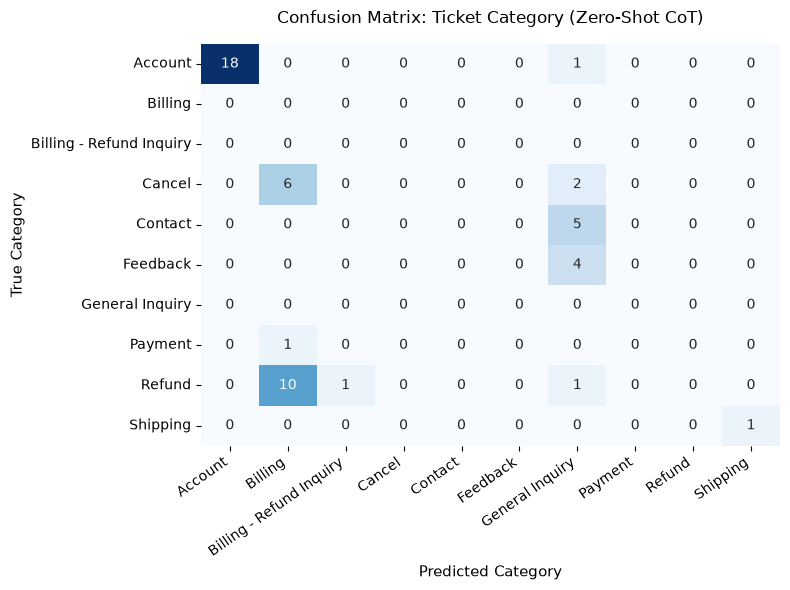

In [36]:
cat_labels: List[str] = sorted(list(set(y_true_cat.unique()) | set(y_pred_cat.unique())))
cm_cat: np.ndarray = confusion_matrix(y_true_cat, y_pred_cat, labels=cat_labels)


fig_cat, ax_cat = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_cat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cat_labels,
    yticklabels=cat_labels,
    cbar=False,
    ax=ax_cat
)

ax_cat.set_title("Confusion Matrix: Ticket Category (Zero-Shot CoT)", pad=15)
ax_cat.set_xlabel("Predicted Category")
ax_cat.set_ylabel("True Category")
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.show()


## 5. Auxiliary Attributes Analysis (Safety & Predicted Sentiment)
Inspecting distributions for auxiliary extracted fields


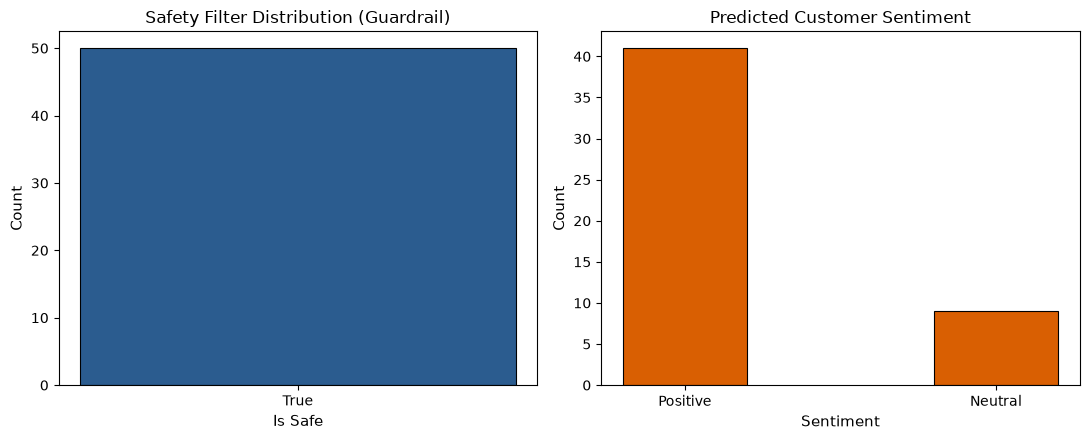

In [ ]:
fig_aux, axes_aux = plt.subplots(1, 2, figsize=(11, 4.5))

# Content Safety distribution (Guardrail)
if 'is_safe' in df_eval.columns:
    safety_counts: pd.Series = df_eval['is_safe'].value_counts()
    axes_aux[0].bar(
        safety_counts.index.astype(str),
        safety_counts.values,
        color='#2b5c8f',
        edgecolor='black',
        linewidth=0.8,
        width=0.4
    )
    axes_aux[0].set_title("Safety Filter Distribution")
    axes_aux[0].set_xlabel("Is Safe")
    axes_aux[0].set_ylabel("Count")

# Predicted Sentiment distribution
if 'predicted_sentiment' in df_eval.columns:
    sentiment_counts: pd.Series = df_eval['predicted_sentiment'].value_counts()
    axes_aux[1].bar(
        sentiment_counts.index.astype(str),
        sentiment_counts.values,
        color='#d95f02',
        edgecolor='black',
        linewidth=0.8,
        width=0.4
    )
    axes_aux[1].set_title("Predicted Customer Sentiment")
    axes_aux[1].set_xlabel("Sentiment")
    axes_aux[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
